In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud openpyxl

In [10]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
data = {
    "complaint_text": [
        "My online banking account is not working",
        "I was charged an incorrect transaction fee",
        "I applied for a loan but it was rejected",
        "I cannot access my bank account",
        "There is an unauthorized transaction on my account",
        "The loan interest rate is too high",
        "My debit card payment failed",
        "I am unable to reset my online banking password",
        "My account has been charged twice",
        "The bank has not processed my loan application"
    ],

    "category": [
        "Online Banking",
        "Transaction",
        "Loan",
        "Account Management",
        "Transaction",
        "Loan",
        "Transaction",
        "Online Banking",
        "Transaction",
        "Loan"
    ]
}

df = pd.DataFrame(data)

print(df.head())
print("\nDataset shape:", df.shape)

                                      complaint_text            category
0           My online banking account is not working      Online Banking
1         I was charged an incorrect transaction fee         Transaction
2           I applied for a loan but it was rejected                Loan
3                    I cannot access my bank account  Account Management
4  There is an unauthorized transaction on my acc...         Transaction

Dataset shape: (10, 2)


In [12]:
print(df.isnull().sum())

complaint_text    0
category          0
dtype: int64


In [13]:
df = df.dropna(subset=["complaint_text", "category"])
df = df.reset_index(drop=True)

print("Remaining records:", len(df))

Remaining records: 10


In [14]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)


df["cleaned_text"] = df["complaint_text"].apply(preprocess_text)

print(df[["complaint_text", "cleaned_text"]].head(10))

                                      complaint_text  \
0           My online banking account is not working   
1         I was charged an incorrect transaction fee   
2           I applied for a loan but it was rejected   
3                    I cannot access my bank account   
4  There is an unauthorized transaction on my acc...   
5                 The loan interest rate is too high   
6                       My debit card payment failed   
7    I am unable to reset my online banking password   
8                  My account has been charged twice   
9     The bank has not processed my loan application   

                           cleaned_text  
0        online banking account working  
1     charged incorrect transaction fee  
2                 applied loan rejected  
3            cannot access bank account  
4      unauthorized transaction account  
5               loan interest rate high  
6             debit card payment failed  
7  unable reset online banking password  
8    

In [18]:
# Select input and target columns

X = df["cleaned_text"]
y = df["category"]

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [19]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

In [20]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [21]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['Loan' 'Transaction']


In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 50.0 %


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Loan       0.00      0.00      0.00         0
 Transaction       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


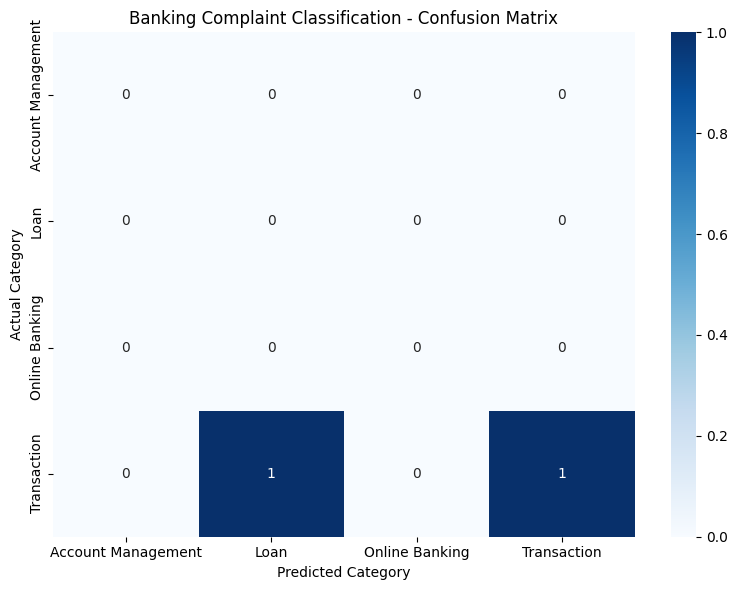

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Banking Complaint Classification - Confusion Matrix")

plt.tight_layout()
plt.show()

In [25]:
new_complaint = [
    "I cannot log into my mobile banking account and my password reset is not working"
]

prediction = model.predict(new_complaint)

print("Complaint:")
print(new_complaint[0])

print("\nPredicted Category:")
print(prediction[0])

Complaint:
I cannot log into my mobile banking account and my password reset is not working

Predicted Category:
Online Banking


In [26]:
new_complaints = [
    "Someone made a transaction using my card",
    "I am having trouble logging into internet banking",
    "My loan application is taking too long",
    "I was charged twice for the same transaction"
]

predictions = model.predict(new_complaints)

for complaint, category in zip(new_complaints, predictions):
    print("Complaint:", complaint)
    print("Category:", category)
    print("-" * 60)

Complaint: Someone made a transaction using my card
Category: Transaction
------------------------------------------------------------
Complaint: I am having trouble logging into internet banking
Category: Online Banking
------------------------------------------------------------
Complaint: My loan application is taking too long
Category: Loan
------------------------------------------------------------
Complaint: I was charged twice for the same transaction
Category: Transaction
------------------------------------------------------------


In [27]:
category_counts = df["category"].value_counts()

print(category_counts)

category
Transaction           4
Loan                  3
Online Banking        2
Account Management    1
Name: count, dtype: int64


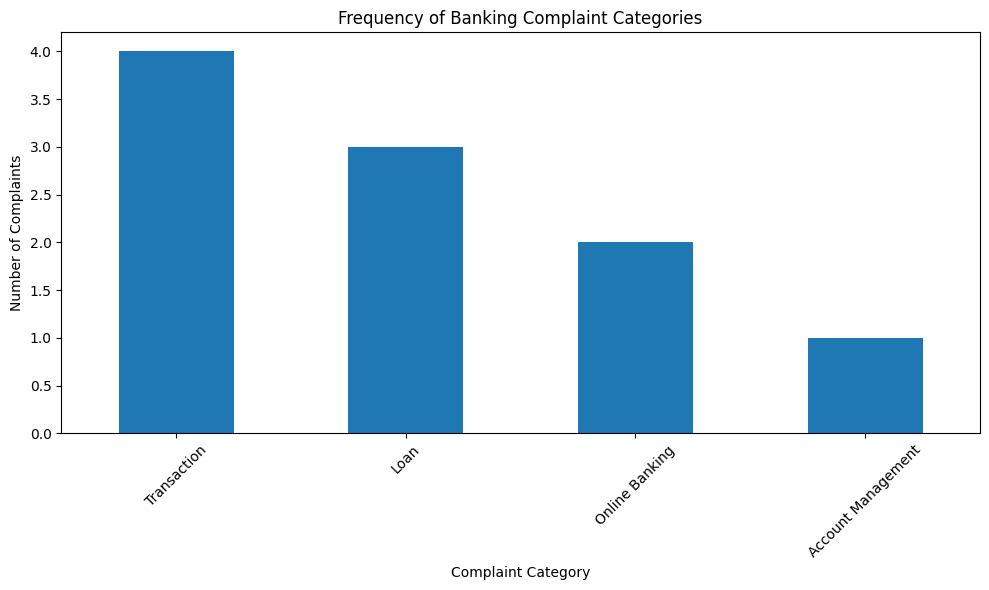

In [28]:
plt.figure(figsize=(10, 6))

category_counts.plot(
    kind="bar"
)

plt.title("Frequency of Banking Complaint Categories")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
all_text = " ".join(df["cleaned_text"])

words = all_text.split()

word_counts = Counter(words)

most_common_words = word_counts.most_common(20)

print("Most Frequent Words:\n")

for word, count in most_common_words:
    print(word, ":", count)

Most Frequent Words:

account : 4
loan : 3
online : 2
banking : 2
charged : 2
transaction : 2
bank : 2
working : 1
incorrect : 1
fee : 1
applied : 1
rejected : 1
cannot : 1
access : 1
unauthorized : 1
interest : 1
rate : 1
high : 1
debit : 1
card : 1


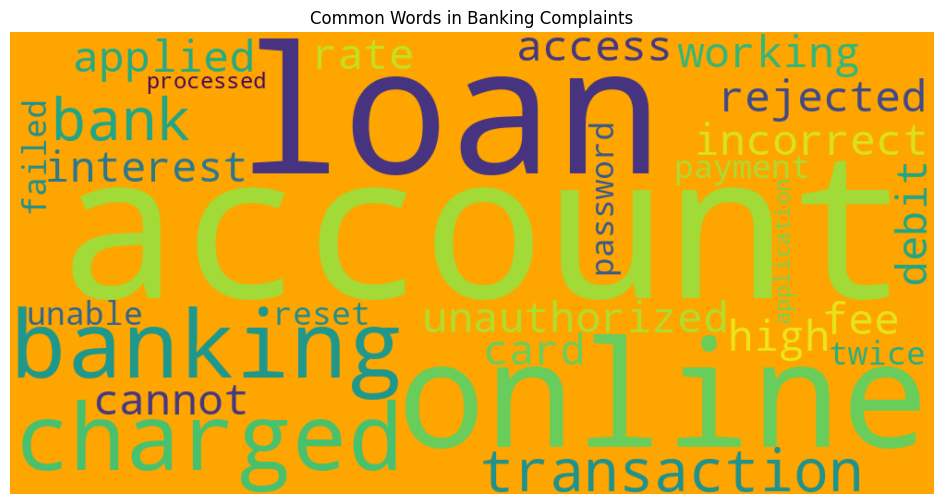

In [31]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="orange",
    stopwords=stop_words
).generate(all_text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Common Words in Banking Complaints")

plt.show()

In [34]:
for category in df["category"].unique():

    category_text = " ".join(
        df[df["category"] == category]["cleaned_text"]
    )

    words = category_text.split()

    common_words = Counter(words).most_common(10)

    print("\nCategory:", category)
    print(common_words)


Category: Online Banking
[('online', 2), ('banking', 2), ('account', 1), ('working', 1), ('unable', 1), ('reset', 1), ('password', 1)]

Category: Transaction
[('charged', 2), ('transaction', 2), ('account', 2), ('incorrect', 1), ('fee', 1), ('unauthorized', 1), ('debit', 1), ('card', 1), ('payment', 1), ('failed', 1)]

Category: Loan
[('loan', 3), ('applied', 1), ('rejected', 1), ('interest', 1), ('rate', 1), ('high', 1), ('bank', 1), ('processed', 1), ('application', 1)]

Category: Account Management
[('cannot', 1), ('access', 1), ('bank', 1), ('account', 1)]
